# Домашнее задание к семинару 14 (HW14)

#### 1. Импорты, seed и среда


In [24]:
import os
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

import faiss

from sentence_transformers import SentenceTransformer
import torch

In [25]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [26]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [73]:
artifacts_path = "artifacts/"
os.makedirs(artifacts_path, exist_ok=True)

#### 2. База знаний и первичный анализ

In [27]:
import json

with open("data/train-v1.1.json", "r", encoding="utf-8") as f:
    squad_data = json.load(f)

articles = squad_data["data"][:15]

documents = []
for article in articles:
    for paragraph in article["paragraphs"]:
        documents.append({
            "title": article["title"],
            "text": paragraph["context"]
        })

print("Число документов:", len(documents))

Число документов: 877


In [28]:
sample_df = pd.DataFrame(documents[:5])
sample_df

,title,text
0,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha..."
1,University_of_Notre_Dame,"As at most other universities, Notre Dame's st..."
2,University_of_Notre_Dame,The university is the major seat of the Congre...
3,University_of_Notre_Dame,The College of Engineering was established in ...
4,University_of_Notre_Dame,All of Notre Dame's undergraduate students are...


In [29]:
for i, doc in enumerate(documents[:5], 1):
    print(f"Документ {i}")
    print("Title:", doc["title"])
    print("Fragment:", doc["text"][:500])
    print("" * 100)

Документ 1
Title: University_of_Notre_Dame
Fragment: Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputed

Документ 2
Title: University_of_Notre_Dame
Fragment: As at most other universities, Notre Dame's students run a number of news media outlets. The nine student-run outlets include three newspapers, both a radio and television station, and several magazines and journals. Begun as a one-page journal in September 1876, the Scholastic magazine is issued twice monthly and claims to be the oldest continuous collegiate publication in the United Stat

#### 3. Чанкинг документов


In [30]:
def chunk_text(text, chunk_size=400, overlap=50):
    chunks = []
    start = 0

    while start < len(text):
        end = start + chunk_size
        chunk = text[start:end]
        chunks.append(chunk)

        if end >= len(text):
            break

        start += chunk_size - overlap

    return chunks

In [31]:
chunk_size = 400
overlap = 50

chunks = []
for doc_id, doc in enumerate(documents):
    doc_chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
    for chunk_id, chunk in enumerate(doc_chunks):
        chunks.append({
            "doc_id": doc_id,
            "chunk_id": chunk_id,
            "title": doc["title"],
            "text": chunk,
            "full_context": doc["text"]
        })

print("Число чанков:", len(chunks))

Число чанков: 2143


In [80]:
sample_doc = documents[0]

print("Заголовок документа:")
print(sample_doc["title"])
print()
print("Фрагмент исходного документа:")
print(sample_doc["text"][:1000])
print()
print()

sample_chunks = chunk_text(sample_doc["text"], chunk_size=chunk_size, overlap=overlap)

for i, chunk in enumerate(sample_chunks[:5], 1):
    print(f"Chunk {i}")
    print(chunk)
    print()

Заголовок документа:
University_of_Notre_Dame

Фрагмент исходного документа:
Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of the main drive (and in a direct line that connects through 3 statues and the Gold Dome), is a simple, modern stone statue of Mary.


Chunk 1
Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ wit

In [33]:
chunk_stats = pd.DataFrame({
    "doc_id": [x["doc_id"] for x in chunks],
    "chunk_id": [x["chunk_id"] for x in chunks],
    "title": [x["title"] for x in chunks],
    "length": [len(x["text"]) for x in chunks]
})

chunk_stats.head()

,doc_id,chunk_id,title,length
0,0,0,University_of_Notre_Dame,400
1,0,1,University_of_Notre_Dame,345
2,1,0,University_of_Notre_Dame,400
3,1,1,University_of_Notre_Dame,400
4,1,2,University_of_Notre_Dame,400


In [81]:
chunk_df = pd.DataFrame(chunks[:50])
chunk_df.to_csv(artifacts_path + "chunk_examples.csv", index=False)

# 4. Эмбеддинги и индекс FAISS

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

chunk_texts = [x["text"] for x in chunks]

vectorizer = TfidfVectorizer(max_features=5000)
chunk_embeddings = vectorizer.fit_transform(chunk_texts).toarray().astype("float32")

print("Shape:", chunk_embeddings.shape)

Shape: (2143, 5000)


In [35]:
dimension = chunk_embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)
index.add(chunk_embeddings)

print("Index size:", index.ntotal)

Index size: 2143


In [36]:
def search_faiss(query, vectorizer, index, chunks, top_k=5):
    query_vector = vectorizer.transform([query]).toarray().astype("float32")
    distances, indices = index.search(query_vector, top_k)

    results = []
    for rank, idx in enumerate(indices[0], 1):
        results.append({
            "rank": rank,
            "title": chunks[idx]["title"],
            "chunk_id": chunks[idx]["chunk_id"],
            "text": chunks[idx]["text"],
            "distance": float(distances[0][rank - 1])
        })
    return results

In [37]:
example_queries = queries[:5]

for item in example_queries:
    query = item["question"]
    print()
    print("Query:", query)
    print("Expected title:", item["title"])
    print()

    results = search_faiss(query, vectorizer, index, chunks, top_k=3)

    for r in results:
        print("Rank:", r["rank"])
        print("Title:", r["title"])
        print("Chunk ID:", r["chunk_id"])
        print("Distance:", round(r["distance"], 4))
        print(r["text"][:500])
        print()


Query: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Expected title: University_of_Notre_Dame

Rank: 1
Title: University_of_Notre_Dame
Chunk ID: 1
Distance: 1.3059
nd the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of the main drive (and in a direct line that connects through 3 statues and the Gold Dome), is a simple, modern stone statue of Mary.

Rank: 2
Title: University_of_Notre_Dame
Chunk ID: 2
Distance: 1.3547
f Lourdes, which was built in 1896, is a replica of the original in Lourdes, France. It is very popular among students and alumni as a place of prayer and meditation, and it is considered one of the most beloved spots on campus.

Rank: 3
Title: University_of_Notre_Dame
Chunk ID: 1
Distance: 1.6557
rench Revival style and it is decorated by stained glass windows imported directly from France

# 5. Контрольные запросы и оценка retrieval

In [38]:
control_queries = []

for q in queries[:10]:
    control_queries.append({
        "query": q["question"],
        "expected_answer": q["answer"],
        "expected_title": q["title"]
    })

control_df = pd.DataFrame(control_queries)
control_df

,query,expected_answer,expected_title
0,To whom did the Virgin Mary allegedly appear i...,Saint Bernadette Soubirous,University_of_Notre_Dame
1,What is in front of the Notre Dame Main Building?,a copper statue of Christ,University_of_Notre_Dame
2,The Basilica of the Sacred heart at Notre Dame...,the Main Building,University_of_Notre_Dame
3,What is the Grotto at Notre Dame?,a Marian place of prayer and reflection,University_of_Notre_Dame
4,What sits on top of the Main Building at Notre...,a golden statue of the Virgin Mary,University_of_Notre_Dame
5,When did the Scholastic Magazine of Notre dame...,September 1876,University_of_Notre_Dame
6,How often is Notre Dame's the Juggler published?,twice,University_of_Notre_Dame
7,What is the daily student paper at Notre Dame ...,The Observer,University_of_Notre_Dame
8,How many student news papers are found at Notr...,three,University_of_Notre_Dame
9,In what year did the student paper Common Sens...,1987,University_of_Notre_Dame


In [41]:
def evaluate_query(query_item, top_k=5):
    results = search_faiss(
        query_item["query"],
        vectorizer,
        index,
        chunks,
        top_k=top_k
    )

    expected_title = query_item["expected_title"]
    expected_answer = query_item["expected_answer"].lower()

    hit_by_title = False
    hit_by_answer = False
    first_relevant_rank = None

    for r in results:
        title_match = r["title"] == expected_title
        answer_match = expected_answer in r["text"].lower()

        if title_match:
            hit_by_title = True

        if answer_match:
            hit_by_answer = True

        if (title_match or answer_match) and first_relevant_rank is None:
            first_relevant_rank = r["rank"]

    return {
        "query": query_item["query"],
        "expected_title": expected_title,
        "expected_answer": query_item["expected_answer"],
        "hit_by_title": int(hit_by_title),
        "hit_by_answer": int(hit_by_answer),
        "first_relevant_rank": first_relevant_rank,
        "mrr": 0 if first_relevant_rank is None else 1 / first_relevant_rank
    }

In [42]:
def evaluate_query(query_item, top_k=5):
    results = search_faiss(
        query_item["query"],
        vectorizer,
        index,
        chunks,
        top_k=top_k
    )

    expected_title = query_item["expected_title"]
    expected_answer = query_item["expected_answer"].lower()

    hit_by_title = False
    hit_by_answer = False
    first_relevant_rank = None

    for r in results:
        title_match = r["title"] == expected_title
        answer_match = expected_answer in r["text"].lower()

        if title_match:
            hit_by_title = True

        if answer_match:
            hit_by_answer = True

        if (title_match or answer_match) and first_relevant_rank is None:
            first_relevant_rank = r["rank"]

    return {
        "query": query_item["query"],
        "expected_title": expected_title,
        "expected_answer": query_item["expected_answer"],
        "hit_by_title": int(hit_by_title),
        "hit_by_answer": int(hit_by_answer),
        "first_relevant_rank": first_relevant_rank,
        "mrr": 0 if first_relevant_rank is None else 1 / first_relevant_rank
    }

In [43]:
def evaluate_retrieval(control_queries, k_values=[1, 3, 5]):
    rows = []

    for k in k_values:
        query_results = []

        for q in control_queries:
            query_results.append(evaluate_query(q, top_k=k))

        df = pd.DataFrame(query_results)

        rows.append({
            "k": k,
            "hit@k_by_title": df["hit_by_title"].mean(),
            "hit@k_by_answer": df["hit_by_answer"].mean(),
            "recall@k_by_title": df["hit_by_title"].mean(),
            "recall@k_by_answer": df["hit_by_answer"].mean(),
            "mrr@k": df["mrr"].mean()
        })

    return pd.DataFrame(rows)

In [44]:
metrics_df = evaluate_retrieval(control_queries, k_values=[1, 3, 5])
metrics_df

,k,hit@k_by_title,hit@k_by_answer,recall@k_by_title,recall@k_by_answer,mrr@k
0,1,1.0,0.4,1.0,0.4,1.0
1,3,1.0,0.8,1.0,0.8,1.0
2,5,1.0,0.8,1.0,0.8,1.0


In [45]:
detailed_results = []

for q in control_queries:
    results = search_faiss(q["query"], vectorizer, index, chunks, top_k=5)

    for r in results:
        detailed_results.append({
            "query": q["query"],
            "expected_title": q["expected_title"],
            "expected_answer": q["expected_answer"],
            "rank": r["rank"],
            "retrieved_title": r["title"],
            "distance": r["distance"],
            "answer_in_chunk": q["expected_answer"].lower() in r["text"].lower(),
            "text_preview": r["text"][:300]
        })

detailed_df = pd.DataFrame(detailed_results)
detailed_df

,query,expected_title,expected_answer,rank,retrieved_title,distance,answer_in_chunk,text_preview
0,To whom did the Virgin Mary allegedly appear i...,University_of_Notre_Dame,Saint Bernadette Soubirous,1,University_of_Notre_Dame,1.305868,True,"nd the basilica is the Grotto, a Marian place ..."
1,To whom did the Virgin Mary allegedly appear i...,University_of_Notre_Dame,Saint Bernadette Soubirous,2,University_of_Notre_Dame,1.354666,False,"f Lourdes, which was built in 1896, is a repli..."
2,To whom did the Virgin Mary allegedly appear i...,University_of_Notre_Dame,Saint Bernadette Soubirous,3,University_of_Notre_Dame,1.655736,False,rench Revival style and it is decorated by sta...
3,To whom did the Virgin Mary allegedly appear i...,University_of_Notre_Dame,Saint Bernadette Soubirous,4,Beyoncé,1.659501,False,"r, Mary J. Blige, Janet Jackson, Anita Baker a..."
4,To whom did the Virgin Mary allegedly appear i...,University_of_Notre_Dame,Saint Bernadette Soubirous,5,University_of_Notre_Dame,1.708954,False,The University of Notre Dame du Lac (or simply...
5,What is in front of the Notre Dame Main Building?,University_of_Notre_Dame,a copper statue of Christ,1,University_of_Notre_Dame,1.209552,True,"Architecturally, the school has a Catholic cha..."
6,What is in front of the Notre Dame Main Building?,University_of_Notre_Dame,a copper statue of Christ,2,University_of_Notre_Dame,1.274865,False,The library system of the university is divide...
7,What is in front of the Notre Dame Main Building?,University_of_Notre_Dame,a copper statue of Christ,3,University_of_Notre_Dame,1.425132,False,The University of Notre Dame du Lac (or simply...
8,What is in front of the Notre Dame Main Building?,University_of_Notre_Dame,a copper statue of Christ,4,University_of_Notre_Dame,1.440210,False,eared under the copyright of the University of...
9,What is in front of the Notre Dame Main Building?,University_of_Notre_Dame,a copper statue of Christ,5,University_of_Notre_Dame,1.494689,False,"The ""Notre Dame Victory March"" is the fight so..."


In [50]:
error_rows = []

for q in control_queries:
    result = evaluate_query(q, top_k=5)

    if result["hit_by_title"] == 0 and result["hit_by_answer"] == 0:
        error_rows.append(result)

errors_df = pd.DataFrame(error_rows)
if errors_df.empty:
    print("Полностью ошибочных запросов в top-5 не найдено.")
else:
    display(errors_df)

Полностью ошибочных запросов в top-5 не найдено.


In [74]:
rows = []

for q in control_queries:
    results = search_faiss(q["query"], vectorizer, index, chunks, top_k=5)

    retrieved_sources = [r["title"] for r in results]

    hit = int(q["expected_title"] in retrieved_sources)

    first_rank = None
    for r in results:
        if r["title"] == q["expected_title"]:
            first_rank = r["rank"]
            break

    rows.append({
        "query": q["query"],
        "expected_source": q["expected_title"],
        "retrieved_sources": ", ".join(retrieved_sources),
        "hit_at_k": hit,
        "rank_of_first_relevant": first_rank
    })

retrieval_eval_df = pd.DataFrame(rows)
retrieval_eval_df

,query,expected_source,retrieved_sources,hit_at_k,rank_of_first_relevant
0,To whom did the Virgin Mary allegedly appear i...,University_of_Notre_Dame,"University_of_Notre_Dame, University_of_Notre_...",1,1
1,What is in front of the Notre Dame Main Building?,University_of_Notre_Dame,"University_of_Notre_Dame, University_of_Notre_...",1,1
2,The Basilica of the Sacred heart at Notre Dame...,University_of_Notre_Dame,"University_of_Notre_Dame, University_of_Notre_...",1,1
3,What is the Grotto at Notre Dame?,University_of_Notre_Dame,"University_of_Notre_Dame, University_of_Notre_...",1,1
4,What sits on top of the Main Building at Notre...,University_of_Notre_Dame,"University_of_Notre_Dame, University_of_Notre_...",1,1
5,When did the Scholastic Magazine of Notre dame...,University_of_Notre_Dame,"University_of_Notre_Dame, University_of_Notre_...",1,1
6,How often is Notre Dame's the Juggler published?,University_of_Notre_Dame,"University_of_Notre_Dame, University_of_Notre_...",1,1
7,What is the daily student paper at Notre Dame ...,University_of_Notre_Dame,"University_of_Notre_Dame, University_of_Notre_...",1,1
8,How many student news papers are found at Notr...,University_of_Notre_Dame,"University_of_Notre_Dame, University_of_Notre_...",1,1
9,In what year did the student paper Common Sens...,University_of_Notre_Dame,"University_of_Notre_Dame, University_of_Notre_...",1,1


In [75]:
retrieval_eval_df.to_csv(
    artifacts_path + "retrieval_eval.csv",
    index=False
)

In [82]:
metrics_df.to_json(
    artifacts_path + "retrieval_metrics_summary.json",
    orient="records",
    indent=2
)

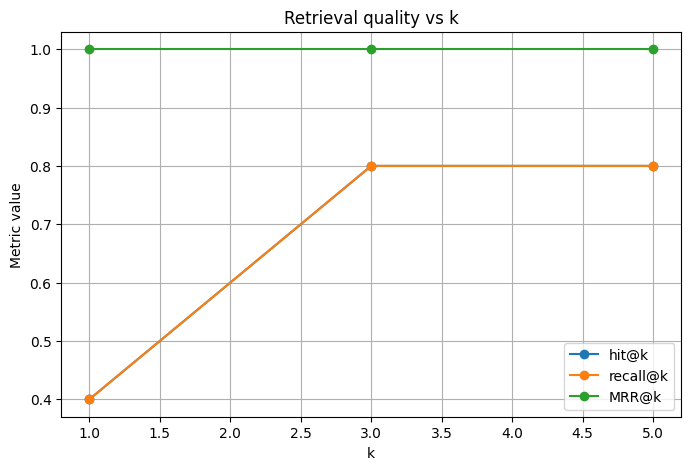

In [83]:
plt.figure(figsize=(8, 5))

plt.plot(metrics_df["k"], metrics_df["hit@k_by_answer"], marker="o", label="hit@k")
plt.plot(metrics_df["k"], metrics_df["recall@k_by_answer"], marker="o", label="recall@k")
plt.plot(metrics_df["k"], metrics_df["mrr@k"], marker="o", label="MRR@k")

plt.xlabel("k")
plt.ylabel("Metric value")
plt.title("Retrieval quality vs k")
plt.legend()
plt.grid(True)

plt.savefig(artifacts_path + "retrieval_quality_plot.png")
plt.show()

# 6. Небольшой эксперимент с параметрами retrieval

In [51]:
def build_chunks(documents, chunk_size, overlap):
    chunks_exp = []

    for doc_id, doc in enumerate(documents):
        doc_chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)

        for chunk_id, chunk in enumerate(doc_chunks):
            chunks_exp.append({
                "doc_id": doc_id,
                "chunk_id": chunk_id,
                "title": doc["title"],
                "text": chunk,
                "full_context": doc["text"]
            })

    return chunks_exp

In [52]:
def build_faiss_index(chunks_exp):
    chunk_texts_exp = [x["text"] for x in chunks_exp]

    vectorizer_exp = TfidfVectorizer(max_features=5000)
    embeddings_exp = vectorizer_exp.fit_transform(chunk_texts_exp).toarray().astype("float32")

    index_exp = faiss.IndexFlatL2(embeddings_exp.shape[1])
    index_exp.add(embeddings_exp)

    return vectorizer_exp, index_exp, embeddings_exp

In [53]:
def run_experiment(chunk_size, overlap=50):
    chunks_exp = build_chunks(documents, chunk_size=chunk_size, overlap=overlap)
    vectorizer_exp, index_exp, embeddings_exp = build_faiss_index(chunks_exp)

    global vectorizer, index, chunks

    old_vectorizer = vectorizer
    old_index = index
    old_chunks = chunks

    vectorizer = vectorizer_exp
    index = index_exp
    chunks = chunks_exp

    metrics = evaluate_retrieval(control_queries, k_values=[1, 3, 5])

    vectorizer = old_vectorizer
    index = old_index
    chunks = old_chunks

    metrics["chunk_size"] = chunk_size
    metrics["overlap"] = overlap
    metrics["num_chunks"] = len(chunks_exp)

    return metrics

In [54]:
experiment1 = run_experiment(chunk_size=300, overlap=50)
experiment2 = run_experiment(chunk_size=600, overlap=50)

experiment_results = pd.concat([experiment1, experiment2], ignore_index=True)
experiment_results

,k,hit@k_by_title,hit@k_by_answer,recall@k_by_title,recall@k_by_answer,mrr@k,chunk_size,overlap,num_chunks
0,1,1.0,0.6,1.0,0.6,1.0,300,50,2811
1,3,1.0,0.6,1.0,0.6,1.0,300,50,2811
2,5,1.0,0.8,1.0,0.8,1.0,300,50,2811
3,1,1.0,0.3,1.0,0.3,1.0,600,50,1513
4,3,1.0,0.6,1.0,0.6,1.0,600,50,1513
5,5,1.0,0.6,1.0,0.6,1.0,600,50,1513


In [55]:
experiment_results[[
    "chunk_size",
    "overlap",
    "num_chunks",
    "k",
    "hit@k_by_answer",
    "recall@k_by_answer",
    "mrr@k"
]]

,chunk_size,overlap,num_chunks,k,hit@k_by_answer,recall@k_by_answer,mrr@k
0,300,50,2811,1,0.6,0.6,1.0
1,300,50,2811,3,0.6,0.6,1.0
2,300,50,2811,5,0.8,0.8,1.0
3,600,50,1513,1,0.3,0.3,1.0
4,600,50,1513,3,0.6,0.6,1.0
5,600,50,1513,5,0.6,0.6,1.0


По результатам эксперимента выбран вариант с параметром chunk_size = 300, так как он показал более высокие значения метрик качества: hit@1 = 0.6 (против 0.3), hit@5 = 0.8 (против 0.6), а также сопоставимые значения MRR = 1.0. Для дальнейших этапов mini-RAG целесообразно использовать данный размер чанка, поскольку он обеспечивает более устойчивое попадание релевантных фрагментов в top-k выдачи.

# 7. Обновление базы знаний и переиндексация

In [56]:
new_documents = [
    {
        "title": "Albert_Einstein",
        "text": "Albert Einstein developed the theory of relativity. He was a German-born theoretical physicist."
    },
    {
        "title": "Nikola_Tesla",
        "text": "Nikola Tesla was born in Smiljan, in modern-day Croatia. He was an inventor and electrical engineer."
    },
    {
        "title": "DNA",
        "text": "DNA is responsible for storing genetic information and instructions used in the development and functioning of living organisms."
    }
]

In [57]:
documents_updated = documents + new_documents

print("До обновления:", len(documents))
print("После обновления:", len(documents_updated))

До обновления: 877
После обновления: 880


In [58]:
chunks_updated = []

for doc_id, doc in enumerate(documents_updated):
    doc_chunks = chunk_text(doc["text"], chunk_size=300, overlap=50)

    for chunk_id, chunk in enumerate(doc_chunks):
        chunks_updated.append({
            "doc_id": doc_id,
            "chunk_id": chunk_id,
            "title": doc["title"],
            "text": chunk
        })

print("Число чанков после обновления:", len(chunks_updated))

Число чанков после обновления: 2814


In [59]:
texts_updated = [x["text"] for x in chunks_updated]

vectorizer_updated = TfidfVectorizer(max_features=5000)
embeddings_updated = vectorizer_updated.fit_transform(texts_updated).toarray().astype("float32")

index_updated = faiss.IndexFlatL2(embeddings_updated.shape[1])
index_updated.add(embeddings_updated)

print("Размер нового индекса:", index_updated.ntotal)

Размер нового индекса: 2814


In [60]:
test_queries = [
    "Who developed the theory of relativity?",
    "Where was Nikola Tesla born?",
    "What is DNA responsible for?"
]

#### Сравнение retrieval

До обновления

In [61]:
for query in test_queries:
    print("\nQuery:", query)

    results = search_faiss(query, vectorizer, index, chunks, top_k=3)

    for r in results:
        print(r["rank"], r["title"])
        print(r["text"][:200])


Query: Who developed the theory of relativity?
1 New_York_City
Sociologists and criminologists have not reached consensus on the explanation for the dramatic decrease in the city's crime rate. Some attribute the phenomenon to new tactics used by the NYPD, includi
2 New_York_City
d other big cities began to fall after lead was removed from American gasoline in the 1970s. Another theory cited to explain New York City's falling homicide rate is the inverse correlation between th
3 University_of_Notre_Dame
m (1851–1921) who was made Professor and Co-Director of the Science Department at age 23 and by 1900 was a nationally prominent scientist and naturalist. Zahm was active in the Catholic Summer School 

Query: Where was Nikola Tesla born?
1 New_York_City
Approximately 37% of the city's population is foreign born. In New York, no single country or region of origin dominates. The ten largest sources of foreign-born individuals in the city as of 2011 wer
2 Beyoncé
Beyoncé Giselle Knowles-Ca

После обновления

In [62]:
for query in test_queries:

    print("\nQuery:", query)

    results = search_faiss(query, vectorizer_updated, index_updated, chunks_updated, top_k=3)

    for r in results:

        print(r["rank"], r["title"])

        print(r["text"][:200])


Query: Who developed the theory of relativity?
1 Albert_Einstein
Albert Einstein developed the theory of relativity. He was a German-born theoretical physicist.
2 New_York_City
Sociologists and criminologists have not reached consensus on the explanation for the dramatic decrease in the city's crime rate. Some attribute the phenomenon to new tactics used by the NYPD, includi
3 Spectre_(2015_film)
hybrid system. The C-X75s used for filming were developed by the engineering division of Formula One racing team Williams, who built the original C-X75 prototype for Jaguar.

Query: Where was Nikola Tesla born?
1 Nikola_Tesla
Nikola Tesla was born in Smiljan, in modern-day Croatia. He was an inventor and electrical engineer.
2 Albert_Einstein
Albert Einstein developed the theory of relativity. He was a German-born theoretical physicist.
3 New_York_City
Approximately 37% of the city's population is foreign born. In New York, no single country or region of origin dominates. The ten largest sour

In [78]:
compare_rows = []

for query in test_queries:
    before_results = search_faiss(query, vectorizer, index, chunks, top_k=3)
    after_results = search_faiss(query, vectorizer_updated, index_updated, chunks_updated, top_k=3)

    before_titles = [r["title"] for r in before_results]
    after_titles = [r["title"] for r in after_results]

    compare_rows.append({
        "query": query,
        "before_retrieved_sources": ", ".join(before_titles),
        "after_retrieved_sources": ", ".join(after_titles),
        "changed": int(before_titles != after_titles)
    })

compare_df = pd.DataFrame(compare_rows)
compare_df

,query,before_retrieved_sources,after_retrieved_sources,changed
0,Who developed the theory of relativity?,"New_York_City, New_York_City, University_of_No...","Albert_Einstein, New_York_City, Spectre_(2015_...",1
1,Where was Nikola Tesla born?,"New_York_City, Beyoncé, New_York_City","Nikola_Tesla, Albert_Einstein, New_York_City",1
2,What is DNA responsible for?,"Antibiotics, Frédéric_Chopin, To_Kill_a_Mockin...","DNA, Antibiotics, 2008_Sichuan_earthquake",1


In [79]:
compare_df.to_csv(
    artifacts_path + "retrieval_before_after_update.csv",
    index=False
)

# 8. Mini-RAG

In [63]:
def mini_rag(query, vectorizer, index, chunks, top_k=3):
    results = search_faiss(
        query=query,
        vectorizer=vectorizer,
        index=index,
        chunks=chunks,
        top_k=top_k
    )

    context_parts = []
    sources = []

    for r in results:
        context_parts.append(r["text"])
        sources.append({
            "rank": r["rank"],
            "title": r["title"],
            "chunk_id": r["chunk_id"],
            "distance": r["distance"]
        })

    context = "\n\n".join(context_parts)

    answer = (
        "Ответ сформирован на основе найденного контекста.\n\n"
        f"Запрос: {query}\n\n"
        "Наиболее релевантная информация:\n"
        f"{context[:1200]}"
    )

    return {
        "query": query,
        "answer": answer,
        "sources": sources,
        "context": context
    }

In [65]:
rag_queries = [
    "Who developed the theory of relativity?",
    "Where was Nikola Tesla born?",
    "What is DNA responsible for?"
]

for query in rag_queries:
    result = mini_rag(
        query=query,
        vectorizer=vectorizer_updated,
        index=index_updated,
        chunks=chunks_updated,
        top_k=3
    )

    print()
    print(result["answer"])
    print("\nИсточники:")
    for source in result["sources"]:
        print(source)


Ответ сформирован на основе найденного контекста.

Запрос: Who developed the theory of relativity?

Наиболее релевантная информация:
Albert Einstein developed the theory of relativity. He was a German-born theoretical physicist.

Sociologists and criminologists have not reached consensus on the explanation for the dramatic decrease in the city's crime rate. Some attribute the phenomenon to new tactics used by the NYPD, including its use of CompStat and the broken windows theory. Others cite the end of the crack epidemic and 

hybrid system. The C-X75s used for filming were developed by the engineering division of Formula One racing team Williams, who built the original C-X75 prototype for Jaguar.

Источники:
{'rank': 1, 'title': 'Albert_Einstein', 'chunk_id': 0, 'distance': 0.8982686996459961}
{'rank': 2, 'title': 'New_York_City', 'chunk_id': 0, 'distance': 1.5713473558425903}
{'rank': 3, 'title': 'Spectre_(2015_film)', 'chunk_id': 4, 'distance': 1.574688196182251}

Ответ сформирован 

In [76]:
rag_rows = []

for q in analysis_queries:
    result = mini_rag(
        query=q,
        vectorizer=vectorizer_updated,
        index=index_updated,
        chunks=chunks_updated,
        top_k=3
    )

    sources = [s["title"] for s in result["sources"]]

    rag_rows.append({
        "question": q,
        "answer": result["answer"],
        "retrieved_sources": ", ".join(sources)
    })

rag_df = pd.DataFrame(rag_rows)
rag_df

,question,answer,retrieved_sources
0,Who developed the theory of relativity?,Ответ сформирован на основе найденного контекс...,"Albert_Einstein, New_York_City, Spectre_(2015_..."
1,Where was Nikola Tesla born?,Ответ сформирован на основе найденного контекс...,"Nikola_Tesla, Albert_Einstein, New_York_City"
2,What is DNA responsible for?,Ответ сформирован на основе найденного контекс...,"DNA, Antibiotics, 2008_Sichuan_earthquake"
3,What is in front of the Notre Dame Main Building?,Ответ сформирован на основе найденного контекс...,"University_of_Notre_Dame, University_of_Notre_..."
4,What is the Grotto at Notre Dame?,Ответ сформирован на основе найденного контекс...,"University_of_Notre_Dame, University_of_Notre_..."


In [77]:
rag_df.to_csv(
    artifacts_path + "rag_examples.csv",
    index=False
)

# 9. Краткий анализ ошибок

Примеры работы mini-RAG

In [66]:
analysis_queries = [
    "Who developed the theory of relativity?",
    "Where was Nikola Tesla born?",
    "What is DNA responsible for?",
    "What is in front of the Notre Dame Main Building?",
    "What is the Grotto at Notre Dame?"
]

analysis_results = []

for query in analysis_queries:
    result = mini_rag(
        query=query,
        vectorizer=vectorizer_updated,
        index=index_updated,
        chunks=chunks_updated,
        top_k=3
    )

    analysis_results.append({
        "query": query,
        "answer": result["answer"][:500],
        "sources": result["sources"]
    })

pd.DataFrame(analysis_results)

,query,answer,sources
0,Who developed the theory of relativity?,Ответ сформирован на основе найденного контекс...,"[{'rank': 1, 'title': 'Albert_Einstein', 'chun..."
1,Where was Nikola Tesla born?,Ответ сформирован на основе найденного контекс...,"[{'rank': 1, 'title': 'Nikola_Tesla', 'chunk_i..."
2,What is DNA responsible for?,Ответ сформирован на основе найденного контекс...,"[{'rank': 1, 'title': 'DNA', 'chunk_id': 0, 'd..."
3,What is in front of the Notre Dame Main Building?,Ответ сформирован на основе найденного контекс...,"[{'rank': 1, 'title': 'University_of_Notre_Dam..."
4,What is the Grotto at Notre Dame?,Ответ сформирован на основе найденного контекс...,"[{'rank': 1, 'title': 'University_of_Notre_Dam..."


Детальный вывод

In [70]:
for item in analysis_results:
    print()
    print("Query :", item["query"])
    print()
    print(item["answer"])
    print()
    print("Sources:")
    for source in item["sources"]:
        print(source)


Query : Who developed the theory of relativity?

Ответ сформирован на основе найденного контекста.

Запрос: Who developed the theory of relativity?

Наиболее релевантная информация:
Albert Einstein developed the theory of relativity. He was a German-born theoretical physicist.

Sociologists and criminologists have not reached consensus on the explanation for the dramatic decrease in the city's crime rate. Some attribute the phenomenon to new tactics used by the NYPD, including its use of CompStat and the broken windows theory. Others cite the 

Sources:
{'rank': 1, 'title': 'Albert_Einstein', 'chunk_id': 0, 'distance': 0.8982686996459961}
{'rank': 2, 'title': 'New_York_City', 'chunk_id': 0, 'distance': 1.5713473558425903}
{'rank': 3, 'title': 'Spectre_(2015_film)', 'chunk_id': 4, 'distance': 1.574688196182251}

Query : Where was Nikola Tesla born?

Ответ сформирован на основе найденного контекста.

Запрос: Where was Nikola Tesla born?

Наиболее релевантная информация:
Nikola Tesla was

Пограничные условия

In [71]:
edge_queries = [
    "Tell me about science",
    "What happened in France?",
    "Who is responsible for information?",
    "Where was he born?"
]

edge_results = []

for query in edge_queries:
    result = mini_rag(
        query=query,
        vectorizer=vectorizer_updated,
        index=index_updated,
        chunks=chunks_updated,
        top_k=3
    )

    edge_results.append({
        "query": query,
        "answer_preview": result["answer"][:500],
        "sources": result["sources"]
    })

pd.DataFrame(edge_results)

,query,answer_preview,sources
0,Tell me about science,Ответ сформирован на основе найденного контекс...,"[{'rank': 1, 'title': 'To_Kill_a_Mockingbird',..."
1,What happened in France?,Ответ сформирован на основе найденного контекс...,"[{'rank': 1, 'title': 'Frédéric_Chopin', 'chun..."
2,Who is responsible for information?,Ответ сформирован на основе найденного контекс...,"[{'rank': 1, 'title': 'DNA', 'chunk_id': 0, 'd..."
3,Where was he born?,Ответ сформирован на основе найденного контекс...,"[{'rank': 1, 'title': 'Albert_Einstein', 'chun..."


Для анализа mini-RAG были рассмотрены успешные и пограничные случаи. В успешных примерах система корректно извлекает релевантные фрагменты, содержащие ответ на вопрос (например, про Эйнштейна или Теслу).

Пограничные случаи связаны с несколькими причинами. Общие запросы (Tell me about science) приводят к размытым результатам из-за отсутствия конкретики. Неоднозначные вопросы (What happened in France?) возвращают разные фрагменты, связанные с упоминанием France. Некорректно сформулированные запросы (Where was he born?) дают нерелевантные результаты из-за отсутствия явного объекта.

В целом ошибки обусловлены формулировкой запросов, ограниченностью базы знаний и использованием TF-IDF, который хуже учитывает семантику текста.